In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Display graphs nicely
%matplotlib inline
sns.set_style("whitegrid")

In [61]:
df = pd.read_csv("Dataset.csv")

In [62]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [63]:
print (df.shape)


(284807, 31)


In [64]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [66]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,...,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [67]:
print (df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [68]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


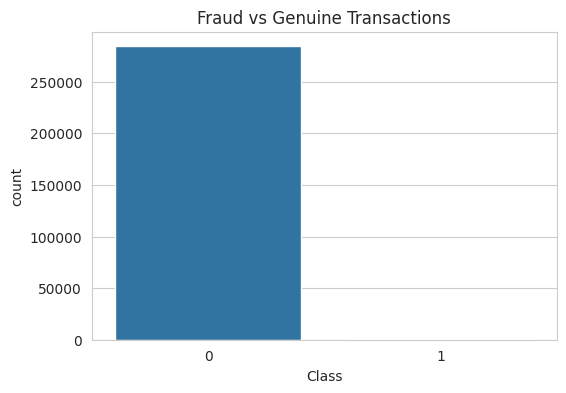

In [69]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [70]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 1081


In [71]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]

print("Fraud Transactions :", fraud)
print("Normal Transactions:", normal)

print("Fraud Percentage:", round((fraud/(fraud+normal))*100,4), "%")

Fraud Transactions : 492
Normal Transactions: 284315
Fraud Percentage: 0.1727 %


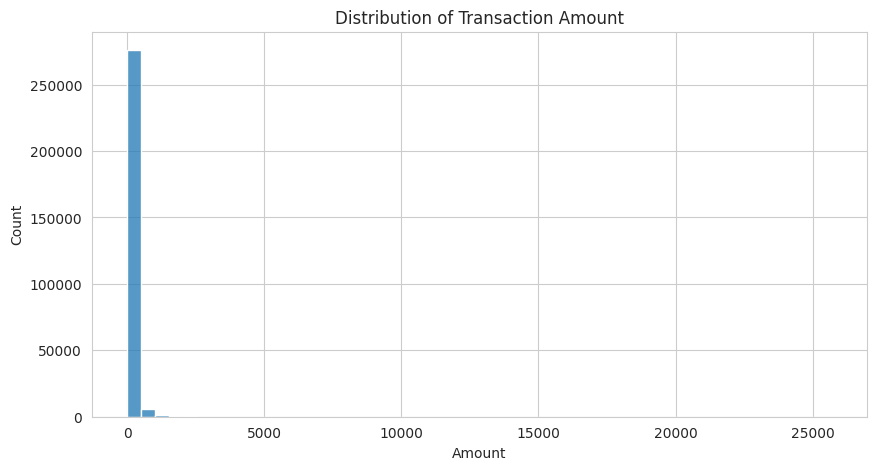

In [72]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title("Distribution of Transaction Amount")

plt.show()

In [73]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


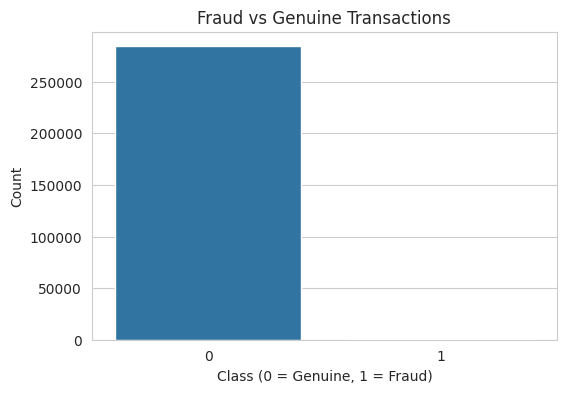

In [74]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [75]:
fraud = df["Class"].value_counts()[1]
total = len(df)

print("Fraud Percentage:", (fraud/total)*100)

Fraud Percentage: 0.1727485630620034


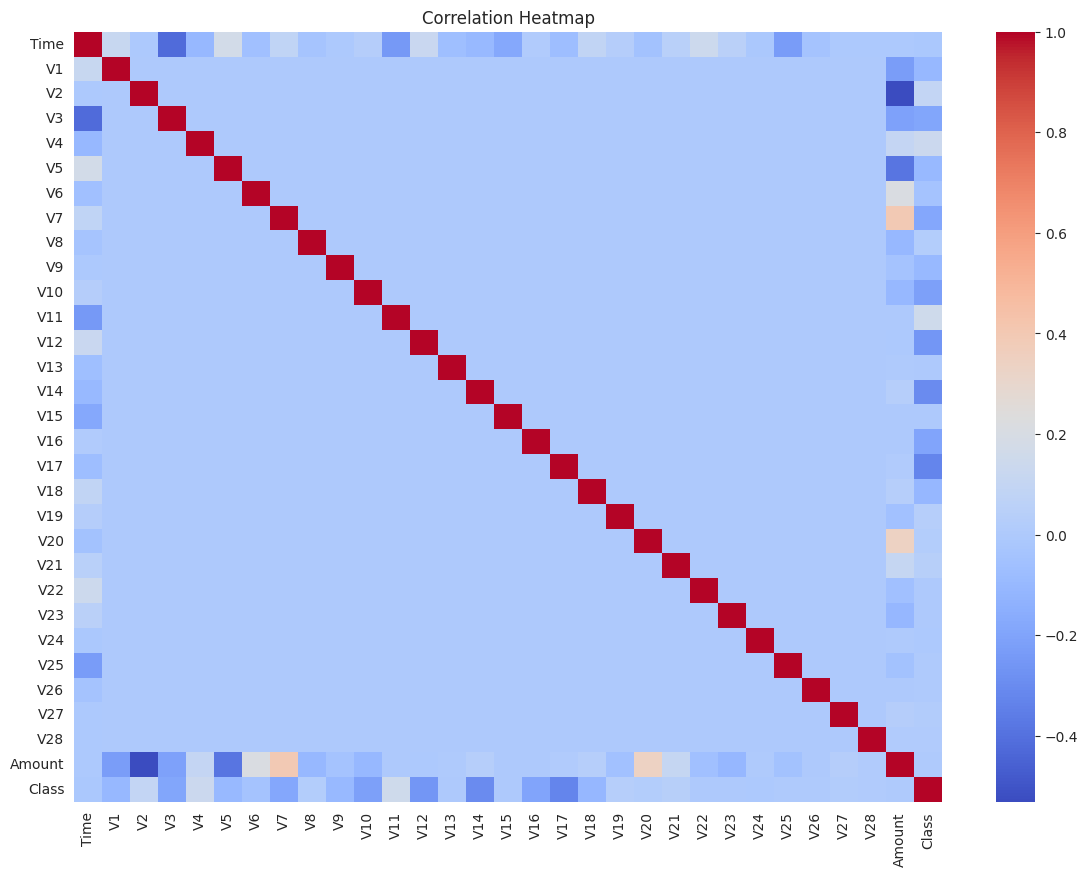

In [76]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

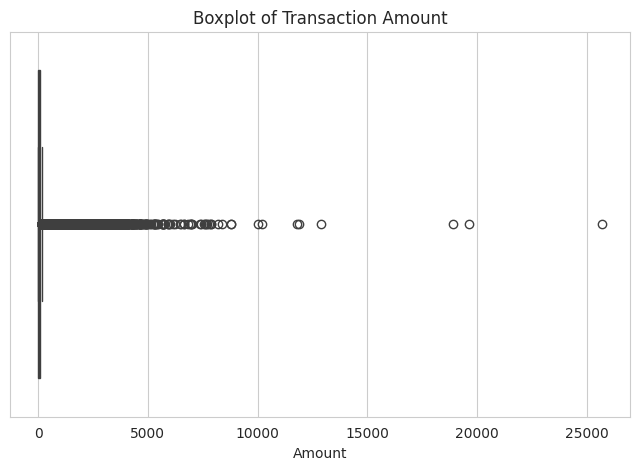

In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount"])
plt.title("Boxplot of Transaction Amount")
plt.show()

In [78]:
fraud = df["Class"].value_counts()[1]
total = len(df)

print("Fraud Percentage:", round((fraud/total)*100,4), "%")

Fraud Percentage: 0.1727 %


In [79]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [80]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [81]:
import numpy as np

print(np.isinf(X).sum().sum())

0


In [82]:
print(df.shape)
print(df.head())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [83]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
dtype: object


In [84]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [85]:
print(df["Class"].isnull().sum())

0


In [86]:
df = df.dropna(subset=["Class"])

In [87]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [88]:
# Remove rows with missing values
df = df.dropna().reset_index(drop=True)

# Check again
print(df.isnull().sum())
print(df.shape)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
(284807, 31)


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
print(df.shape)

print(df.duplicated().sum())

print(df["Class"].value_counts())

(284807, 31)
1081
Class
0    284315
1       492
Name: count, dtype: int64


In [91]:
print("Duplicate rows before:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after:", df.duplicated().sum())
print("Shape after dropping duplicates:", df.shape)

Duplicate rows before: 1081
Duplicate rows after: 0
Shape after dropping duplicates: (283726, 31)


Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud Percentage: 0.1667%


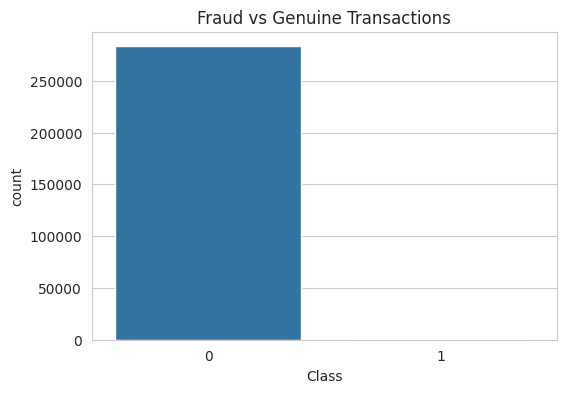

In [92]:
print("Class distribution:")
print(df["Class"].value_counts())

fraud_count = df["Class"].value_counts()[1]
total = len(df)
fraud_pct = (fraud_count / total) * 100

print(f"\nFraud Percentage: {fraud_pct:.4f}%")
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [93]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

print("\nClass distribution in train:")
print(y_train.value_counts())

print("\nClass distribution in test:")
print(y_test.value_counts())

Train size: (226980, 30)
Test size : (56746, 30)

Class distribution in train:
Class
0    226602
1       378
Name: count, dtype: int64

Class distribution in test:
Class
0    56651
1       95
Name: count, dtype: int64


In [95]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
!pip install -q imbalanced-learn

In [97]:
from imblearn.over_sampling import SMOTE

In [98]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE - Train size:", X_train_smote.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE - Train size: (453204, 30)

Class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [99]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE - Train size:", X_train_smote.shape)
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE - Train size: (453204, 30)

Class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [100]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score
)

In [101]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, digits=4))

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
pr_auc_lr  = average_precision_score(y_test, y_prob_lr)

print(f"\nROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC : {pr_auc_lr:.4f}")

Confusion Matrix:
[[55169  1482]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9738    0.9866     56651
           1     0.0530    0.8737    0.1000        95

    accuracy                         0.9737     56746
   macro avg     0.5264    0.9238    0.5433     56746
weighted avg     0.9982    0.9737    0.9852     56746


ROC-AUC: 0.9626
PR-AUC : 0.6750


In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

In [103]:
from sklearn.preprocessing import StandardScaler

In [104]:
from imblearn.over_sampling import SMOTE

In [109]:


rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf  = average_precision_score(y_test, y_prob_rf)

print(f"\nROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC : {pr_auc_rf:.4f}")

Confusion Matrix:
[[56644     7]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9997     56651
           1     0.9125    0.7684    0.8343        95

    accuracy                         0.9995     56746
   macro avg     0.9561    0.8841    0.9170     56746
weighted avg     0.9995    0.9995    0.9995     56746


ROC-AUC: 0.9694
PR-AUC : 0.8115


In [110]:
print(f"PR-AUC: {pr_auc_rf:.4f}")

PR-AUC: 0.8115


In [111]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4))

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb  = average_precision_score(y_test, y_prob_xgb)

print(f"\nROC-AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC : {pr_auc_xgb:.4f}")

Confusion Matrix:
[[56573    78]
 [   17    78]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9986    0.9992     56651
           1     0.5000    0.8211    0.6215        95

    accuracy                         0.9983     56746
   macro avg     0.7498    0.9098    0.8103     56746
weighted avg     0.9989    0.9983    0.9985     56746


ROC-AUC: 0.9672
PR-AUC : 0.7983


In [112]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]

roc_aucs = [roc_auc_lr, roc_auc_rf, roc_auc_xgb]
pr_aucs  = [pr_auc_lr,  pr_auc_rf,  pr_auc_xgb]

f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

recall_scores = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]

comparison = pd.DataFrame({
    "Model": models,
    "ROC-AUC": roc_aucs,
    "PR-AUC": pr_aucs,
    "F1": f1_scores,
    "Recall": recall_scores
})

print("\nModel Comparison:")
comparison.sort_values("PR-AUC", ascending=False)


Model Comparison:


,Model,ROC-AUC,PR-AUC,F1,Recall
1,Random Forest,0.969422,0.811482,0.834286,0.768421
2,XGBoost,0.967195,0.798305,0.621514,0.821053
0,Logistic Regression,0.962618,0.675041,0.100000,0.873684


In [120]:
!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Best model
best_model = rf

# Test data as DataFrame
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Sample for SHAP
sample_size = min(1000, len(X_test_df))
sample_idx = np.random.choice(X_test_df.index, size=sample_size, replace=False)
X_sample = X_test_df.loc[sample_idx]

# Explainer
explainer = shap.TreeExplainer(best_model)

# SHAP values
shap_values = explainer.shap_values(X_sample)

# If binary classification, use class 1 SHAP values when list is returned
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

<Figure size 1000x600 with 0 Axes>

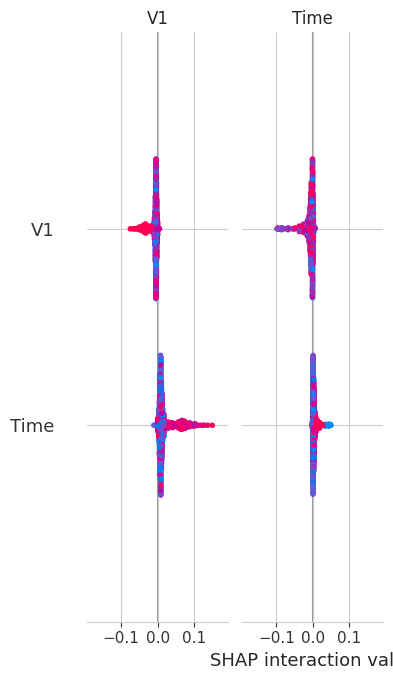

In [122]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_plot,
    X_sample,
    feature_names=X_sample.columns,
    plot_type="bar",
    show=True
)
plt.show()

<Figure size 1000x600 with 0 Axes>

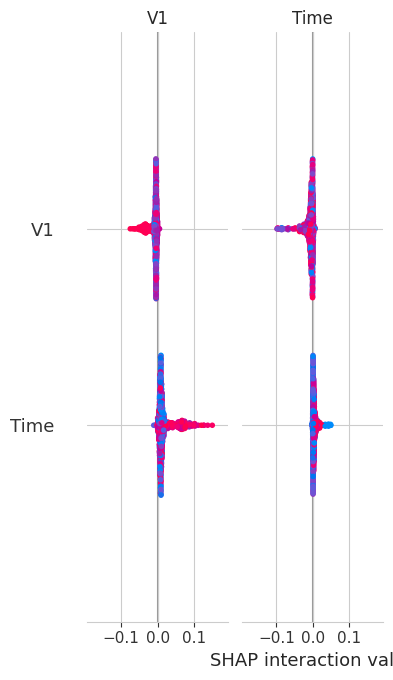

In [121]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_plot,
    X_sample,
    feature_names=X_sample.columns,
    show=True
)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


True Label: 1
Predicted: 1
Fraud Probability: 0.9900


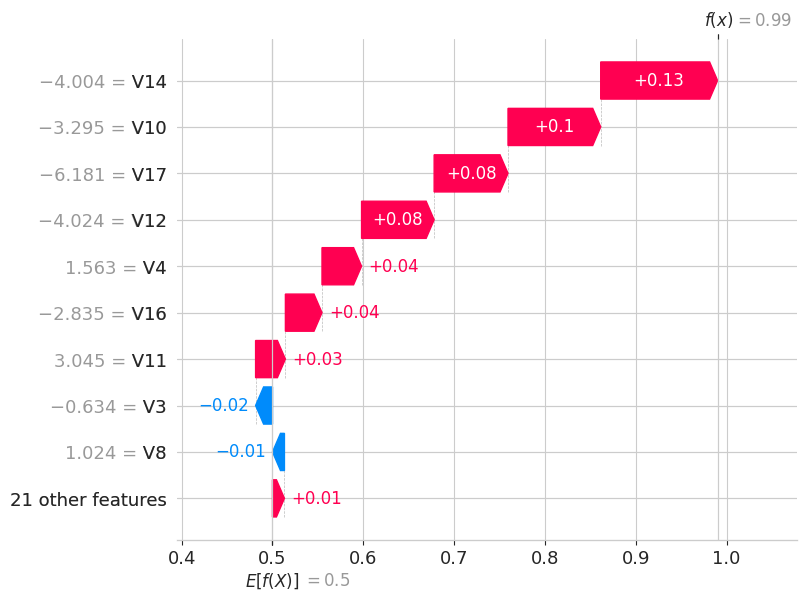

In [123]:
# Find one fraud transaction in test data
fraud_indices = y_test[y_test == 1].index

if len(fraud_indices) > 0:
    fraud_idx = fraud_indices[0]

    # Convert original index to positional index inside X_test_df
    position_in_X_test = X_test.index.get_loc(fraud_idx)
    X_fraud = X_test_df.iloc[[position_in_X_test]]

    # Prediction
    pred = best_model.predict(X_fraud)[0]
    prob = best_model.predict_proba(X_fraud)[0][1]

    print(f"True Label: {y_test.loc[fraud_idx]}")
    print(f"Predicted: {pred}")
    print(f"Fraud Probability: {prob:.4f}")

    # Create explanation object
    fraud_explanation = explainer(X_fraud)

    # For RandomForest binary classification, select output class 1
    shap.plots.waterfall(fraud_explanation[0, :, 1], max_display=10)
else:
    print("No fraud transactions in test set.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


True Label: 0
Predicted: 0
Fraud Probability: 0.0000


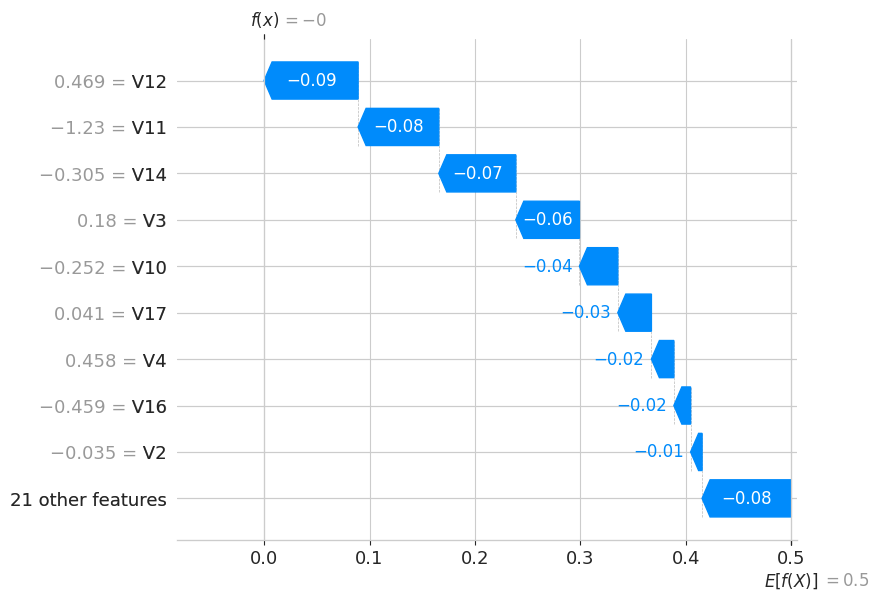

In [124]:
# Find one genuine transaction in test data
genuine_indices = y_test[y_test == 0].index

if len(genuine_indices) > 0:
    genuine_idx = genuine_indices[0]

    # Convert original index to positional index inside X_test_df
    position_in_X_test = X_test.index.get_loc(genuine_idx)
    X_genuine = X_test_df.iloc[[position_in_X_test]]

    # Prediction
    pred = best_model.predict(X_genuine)[0]
    prob = best_model.predict_proba(X_genuine)[0][1]

    print(f"True Label: {y_test.loc[genuine_idx]}")
    print(f"Predicted: {pred}")
    print(f"Fraud Probability: {prob:.4f}")

    # Create explanation object
    genuine_explanation = explainer(X_genuine)

    # For RandomForest binary classification, select output class 1
    shap.plots.waterfall(genuine_explanation[0, :, 1], max_display=10)
else:
    print("No genuine transactions in test set.")

In [125]:
import joblib

joblib.dump(rf, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Saved: fraud_model.pkl")
print("Saved: scaler.pkl")
print("Saved: feature_columns.pkl")

Saved: fraud_model.pkl
Saved: scaler.pkl
Saved: feature_columns.pkl


In [126]:
from google.colab import files

files.download("fraud_model.pkl")
files.download("scaler.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>